In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [2]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000228018A6510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022802AF63C0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

###  **Schema**

In [4]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    topic: str
    x_post: str
    in_post: str
    insta_post: str

In [22]:
def create_post_x(state: graph_schema) -> graph_schema:
    topic = state['topic']

    post = llm.invoke(f"Write a caption about {topic} for X platform. Keep the tone quick").content

    state['x_post'] = post

    return {'x_post' : post}

In [23]:
def create_post_linkedin(state: graph_schema) -> graph_schema:
    topic = state['topic']

    post = llm.invoke(f"Write a caption about {topic} for LinkedIn platform. Keep the tone professional").content

    state['in_post'] = post

    return {'in_post' : post}

In [24]:
def create_post_insta(state: graph_schema) -> graph_schema:
    topic = state['topic']

    post = llm.invoke(f"Write a caption about {topic} for Instagram platform. Keep the tone casual and engaging").content

    state['insta_post'] = post

    return {'insta_post' : post}

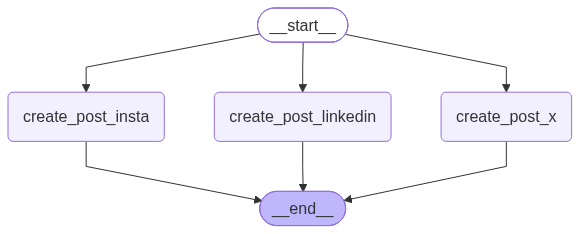

In [25]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

graph.add_node("create_post_x", create_post_x)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "create_post_insta")
graph.add_edge(START,"create_post_linkedin")
graph.add_edge(START,"create_post_x")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_linkedin", END)
graph.add_edge("create_post_x", END)

parallel_graph = graph.compile()

Image(parallel_graph.get_graph().draw_mermaid_png())

In [26]:
parallel_graph.invoke({
    "topic":"The importance of AI in present world",
    "x_post":"",
    "insta_post":"",
    "in_post":"",
})

{'topic': 'The importance of AI in present world',
 'x_post': 'AI is the pulse of today’s breakthroughs—powering everything from health to finance and redefining how we live, work, and think. 🚀 #AI #FutureNow',
 'in_post': 'Artificial Intelligence is reshaping every industry—from accelerating drug discovery to optimizing supply chains—making data‑driven decisions faster, smarter, and more scalable. Embracing AI today isn’t just a competitive edge; it’s a strategic imperative for sustainable growth. #AI #Innovation #DigitalTransformation #FutureOfWork #Leadership.',
 'insta_post': 'AI is the silent sidekick that’s powering everything from your playlist 🎧 to your coffee order ☕️—making life smarter, faster, and way more fun! 🚀 #AIEveryday #FutureNow #TechLife #StayCurious'}